In [1]:
from datetime import datetime

import torch
import wandb
from torch.optim import AdamW

from kolmogorov_flow_matching import (
    ConditionalFlowMatching,
    ConditionalUnetBackbone,
    TimeseriesDataset,
    download_train_set,
    download_valid_set,
    save_checkpoint,
    train_conditional_generative_model,
    visualize_frames,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Downloading/Locating datasets...


Computing global statistics for ../data/valid/valid/KolmFlow_valid_256.h5...
Done! Mean: 0.00000, Std: 3.50252
Computing global statistics for ../data/train/train/KolmFlow_train_1024.h5...
Done! Mean: 0.00000, Std: 3.50582
Detected target shape: Channels=1, Time Steps=1, Height=160, Width=160


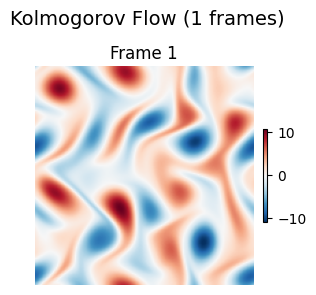

In [2]:
k_frames = 4  # Number of history frames to condition on
target_steps = 10  # Number of future steps to predict

print("Downloading/Locating datasets...")
train_h5_path = download_train_set("../data/train")
valid_h5_path = download_valid_set("../data/valid")

# The dataset will automatically compute and print the mean/std on initialization
valid_set = TimeseriesDataset(
    h5_file_path=valid_h5_path,
    k_frames=k_frames,
    target_steps=target_steps,
    dataset_key="valid/u",
)
train_set = TimeseriesDataset(
    h5_file_path=train_h5_path, k_frames=k_frames, target_steps=1, dataset_key="train/u"
)
sample_batch = train_set[0]
c, t, h, w = sample_batch["target"].shape
print(f"Detected target shape: Channels={c}, Time Steps={t}, Height={h}, Width={w}")
visualize_frames(sample_batch["target"])

backbone = ConditionalUnetBackbone(data_shape=[c, h, w], k_frames=k_frames).to(device)
model = ConditionalFlowMatching(
    backbone=backbone, mean=train_set.mean, std=train_set.std
).to(device)

In [ ]:
num_epochs = 1
batch_size = 16
num_val_batches = 4
max_grad_norm = 1.0
learn_rate = 1e-4
use_wandb = True

if use_wandb:
    dt = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
    run = wandb.init(
        project="kolmogorov-flow-matching",
        name=f"flow_matching_{dt}",
        config={
            "max_grad_norm": max_grad_norm,
            "learning_rate": learn_rate,
            "batch_size": batch_size,
            "num_val_batches": num_val_batches,
            "epochs": num_epochs,
            "model_type": "ConditionalDiffusion+Unet",
        },
    )

optimizer = AdamW(model.parameters(), lr=learn_rate)

final_epoch_loss = train_conditional_generative_model(
    model,
    train_set,
    valid_set,
    optimizer,
    num_epochs,
    batch_size,
    max_grad_norm,
    num_val_batches=num_val_batches,
    device=device,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/user3/.netrc.
wandb: Currently logged in as: derekfan-18-2002 (derekfan-18-2002-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Starting training on cuda (WandB: True)


Epoch 1:   0%|          | 0/12608 [00:00<?, ?it/s]

Validating [Step 1]:   0%|          | 0/4 [00:00<?, ?it/s]

wandb: WARNING Data passed to `wandb.Image` should consist of values in the range [0, 255], image data will be normalized to this range, but behavior will be removed in a future version of wandb.


Validating [Step 4000]:   0%|          | 0/4 [00:00<?, ?it/s]

Validating [Step 8000]:   0%|          | 0/4 [00:00<?, ?it/s]

Validating [Step 12000]:   0%|          | 0/4 [00:00<?, ?it/s]

In [5]:
from pathlib import Path

Path("../checkpoints/").mkdir(parents=True, exist_ok=True)
save_checkpoint(
    "../checkpoints/flow_matching.pt",
    model,
    optimizer,
    final_epoch_loss,
    num_epochs,
)

Checkpoint saved to ../checkpoints/flow_matching.pt
